# CTAO 1D ON/OFF Spectrum Analysis

This notebook demonstrates how to configure and run a 1D ON/OFF spectrum analysis with FeuPy using a source from the 1LHAASO catalog.

The workflow includes target selection, annual visibility, CTAO configuration, observation simulation, spectral fitting, flux-point estimation, sensitivity computation, and basic visualization.

In [2]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst

import astropy.units as u
import gammapy
import matplotlib.pyplot as plt
from gammapy.catalog import SourceCatalog1LHAASO
from gammapy.modeling.models import Models, PowerLawSpectralModel, SkyModel
from gammapy.utils.scripts import make_path

import feupy
from feupy.analysis.config import CTAOAnalysisConfig
from feupy.analysis.core import CTAOAnalysis
from feupy.irf import CTAOVisibilityEstimator, make_ctao_visibility_table
from feupy.utils.coordinates import convert_skycoord_to_dict
from feupy.visualization import FEUPY_MPL_STYLE
from feupy.visualization.counts import show_hist_counts
from feupy.visualization.sensitivity import (
    plot_irfs,
    plot_sensitivity_from_table,
)

plt.style.use(make_path(FEUPY_MPL_STYLE))

print("FeuPy version:", feupy.__version__)
print("Gammapy version:", gammapy.__version__)

FeuPy version: 0.1.0
Gammapy version: 2.0


## Select a target source

In [3]:
catalog = SourceCatalog1LHAASO()
source = catalog["1LHAASO J2002+3244u"]

position = source.position.icrs
source

## Annual visibility

Estimate the target visibility from the CTAO sites for the selected year.

In [4]:
estimator = CTAOVisibilityEstimator(
    target=position,
    year=2026,
    time_step_min=30,
)

visibility_table = make_ctao_visibility_table(estimator)
visibility_table

cta_north: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 365/365 [00:18<00:00, 19.85it/s]


,Observatory,Zenith (deg),Visibility (hours)
3,CTAO North,20,419.5
4,CTAO North,40,418.0
5,CTAO North,60,440.5
0,CTAO South,20,0.0
1,CTAO South,40,0.0
2,CTAO South,60,491.5


## Configure the CTAO analysis

In [5]:
config = CTAOAnalysisConfig()

config.observation.obs_cone = convert_skycoord_to_dict(position)
config.observation.position_angle = 0 * u.deg
config.observation.offset = 0.5 * u.deg
config.observation.livetime = 50 * u.h
config.observation.required_irfs = [
    "South",
    "AverageAz",
    "40deg",
    "50h",
]

config.datasets.map_selection = [
    "edisp",
    "background",
    "exposure",
]

config.datasets.safe_mask.methods = ["aeff-default"]
config.datasets.safe_mask.parameters = {"aeff_percent": 10}
config.datasets.containment_correction = False
config.datasets.use_region_center = True

config.datasets.on_region = convert_skycoord_to_dict(position)
config.datasets.on_region.radius = 0.2 * u.deg

config.datasets.stack = False
config.datasets.on_off.acceptance = 1
config.datasets.on_off.acceptance_off = 5

config.datasets.geom.axes.energy.min = 3 * u.GeV
config.datasets.geom.axes.energy.max = 100 * u.TeV
config.datasets.geom.axes.energy.nbins = 15

config.datasets.geom.axes.energy_true.min = 0.3 * u.GeV
config.datasets.geom.axes.energy_true.max = 300 * u.TeV
config.datasets.geom.axes.energy_true.nbins = 20

config.flux_points.energy.min = 3 * u.GeV
config.flux_points.energy.max = 100 * u.TeV
config.flux_points.energy.nbins = 15
config.flux_points.source = "source"

config.sensitivity.gamma_min = 3
config.sensitivity.n_sigma = 2
config.sensitivity.bkg_syst_fraction = 0.05

config.statistics.n_obs = 1

print(config)

CTAOAnalysisConfig

    general:
        log: {level: info, filename: null, filemode: null, format: null, datefmt: null}
        outdir: .
        n_jobs: 1
        datasets_file: null
        models_file: null
    observation:
        obs_cone: {frame: icrs, lon: 300.6399932258911 deg, lat: 32.73999395571273 deg,
            radius: null}
        livetime: 50.0 h
        offset: 0.5 deg
        position_angle: 0.0 deg
        required_irfs: [South, AverageAz, 40deg, 50h]
    datasets:
        type: 1d
        stack: false
        geom:
            wcs:
                skydir: {frame: null, lon: null, lat: null}
                binsize: 0.02 deg
                width: {width: 5.0 deg, height: 5.0 deg}
                binsize_irf: 0.2 deg
            selection: {offset_max: 2.5 deg}
            axes:
                energy: {min: 3.0 GeV, max: 100.0 TeV, nbins: 15}
                energy_true: {min: 0.3 GeV, max: 300.0 TeV, nbins: 20}
        map_selection: [edisp, background, exposure]

## Simulate the observation

In [6]:
analysis = CTAOAnalysis(config)
analysis.simulate_observation()

Setting logging config: {'level': 'INFO', 'filename': None, 'filemode': None, 'format': None, 'datefmt': None}
Observation 0 created


## Define the source model

For this example, use a simple power-law spectrum as the simulated source model.

In [7]:
spectral_model = PowerLawSpectralModel(
    index=2.21,
    amplitude=3.4e-14 * u.Unit("cm-2 s-1 TeV-1"),
    reference=3 * u.TeV,
)

source_model = SkyModel(
    spectral_model=spectral_model,
    name="source",
)

## Build the spectrum dataset

In [8]:
analysis.get_spectrum_dataset(source_model)
print(analysis.spectrum_dataset)


Corrected exposure (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 27729.67
  Total excess counts             : -27729.67

  Predicted counts                : 27729.67
  Predicted background counts     : 27729.67
  Predicted excess counts         : nan

  Exposure min                    : 4.09e-10 m2 s
  Exposure max                    : 4.00e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 15 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




Corrected background (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 12031.14
  Total excess counts             : -120

SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 14358 
  Total background counts         : 12031.14
  Total excess counts             : 2326.86

  Predicted counts                : 14252.29
  Predicted background counts     : 12031.14
  Predicted excess counts         : 2221.16

  Exposure min                    : 4.09e-10 m2 s
  Exposure max                    : 4.00e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 11 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : -210955.37

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 2

  Component 0: SkyModel
  
    Name                      : source
    Datasets names            : None
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : 
    Temporal model type       : 
    Parameters:
      index                      

In [9]:
analysis.get_datasets()
analysis.set_models(Models(source_model))

analysis.datasets.info_table()

Reading model.
Models

Component 0: SkyModel

  Name                      : source
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : 
  Temporal model type       : 
  Parameters:
    index                         :      2.210   +/-    0.00             
    amplitude                     :   3.40e-14   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      3.000       TeV         




name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
obs-0,14349,2329.999999999998,18.72319566701297,12019.000000000002,14252.588552758922,12031.429294582023,2221.159258176899,4.0947089427510584e-10,400053877365.51337,180000.0,180000.0,0.07971666666666667,0.06677222222222223,0.012944444444444434,15,11,wstat,11.36153671897111,60095,11.0,54.999999999999986,0.20000000000000004


## Fit the spectrum

In [10]:
analysis.run_fit()
analysis.fit_result.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.1986e+00,,2.548e-02,nan,nan,False,,
,amplitude,3.5697e-14,TeV-1 s-1 cm-2,1.437e-15,nan,nan,False,,
,reference,3.0000e+00,TeV,0.000e+00,nan,nan,True,,


## Estimate flux points

In [11]:
analysis.get_flux_points()
analysis.flux_points

In [12]:
analysis.flux_points.data.to_table()

Inferred format: gadf-sed


e_ref,e_min,e_max,ref_dnde,ref_flux,ref_eflux,norm,norm_err,ts,sqrt_ts,npred,npred_excess,stat,stat_null,counts,success
GeV,GeV,GeV,1 / (TeV s cm2),1 / (s cm2),erg / (s cm2),,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[1],float32[1],float64,float64,float64[1],bool
4.245060455378107,3.0000000000000004,6.0068460899383265,6.562323012313013e-08,1.99040472670874e-10,1.316495036269108e-12,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
8.499808265979931,6.0068460899383265,12.027399982735789,1.4259842926543018e-08,8.660117454474337e-11,1.1469034616862514e-12,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
17.01901334924234,12.027399982735789,24.082246852806918,3.0986454020648207e-09,3.767959014511806e-11,9.991587618557671e-13,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
34.07686459716817,24.082246852806918,48.21945011490426,6.733316332584007e-10,1.6394136926752063e-11,8.70446611021087e-13,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
68.23149362095243,48.21945011490426,96.54893846056295,1.4631409197203178e-10,7.132979009006505e-12,7.583152263318378e-13,1.3973313721836447,0.6193869062688794,5.228163614607183,2.2865177923224613,2689.7170556459255,127.663155,3.543362254276872e-05,5.228199048229726,2690.0,True
136.6186935558901,96.54893846056295,193.31820449317635,3.1793862715171977e-11,3.1035113205564455e-12,6.606286648783063e-13,1.0092134473605665,0.13519256994901666,58.07772470661439,7.620874274426418,8545.996809335797,750.59625,1.3969838619232178e-09,58.077724708011374,8546.0,True
273.5491550662272,193.31820449317635,387.07756692457804,6.908765196345056e-12,1.3503169579863271e-12,5.755261370261758e-13,1.029327607369296,0.10031959301036611,120.09438595901884,10.958758413206253,1830.9366449799493,470.52722,2.5180052034556866e-06,120.09438847702404,1831.0,True
547.722557505166,387.07756692457804,775.0384564612474,1.5012657306169894e-12,5.875138508270468e-13,5.013865610286349e-13,1.0019617936678873,0.0738799556006979,271.8414431723322,16.487614841823913,555.9994561946949,332.3994,5.748006515204906e-10,271.841443172907,556.0,True


## Compute sensitivity

The sensitivity table is computed in memory. To save it, call `analysis.write_table_sensitivity()` explicitly.

In [13]:
analysis.compute_sensitivity()
sensitivity_table = analysis.table_sens
sensitivity_table

/home/phoenix/miniconda3/envs/feupy/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Inferred format: gadf-sed


e_ref,e_min,e_max,e2dnde,excess,background,criterion
GeV,GeV,GeV,erg / (s cm2),,,
float64,float64,float64,float64,float64,float64,bytes12
4.24506,3,6.00685,inf,3,0,gamma
8.49981,6.00685,12.0274,inf,3,0,gamma
17.019,12.0274,24.0822,inf,3,0,gamma
34.0769,24.0822,48.2195,5.82989e-11,3,0,gamma
68.2315,48.2195,96.5489,1.53793e-12,129.35,2587,bkg
136.619,96.5489,193.318,5.06726e-13,389.61,7792.2,bkg
273.549,193.318,387.078,1.48912e-13,81.3648,1347.8,significance
547.723,387.078,775.038,7.3946e-14,33.6764,223.4,significance


## Plot the sensitivity

<Axes: xlabel='Energy [$\\mathrm{GeV}$]', ylabel='Flux Sensitivity [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>

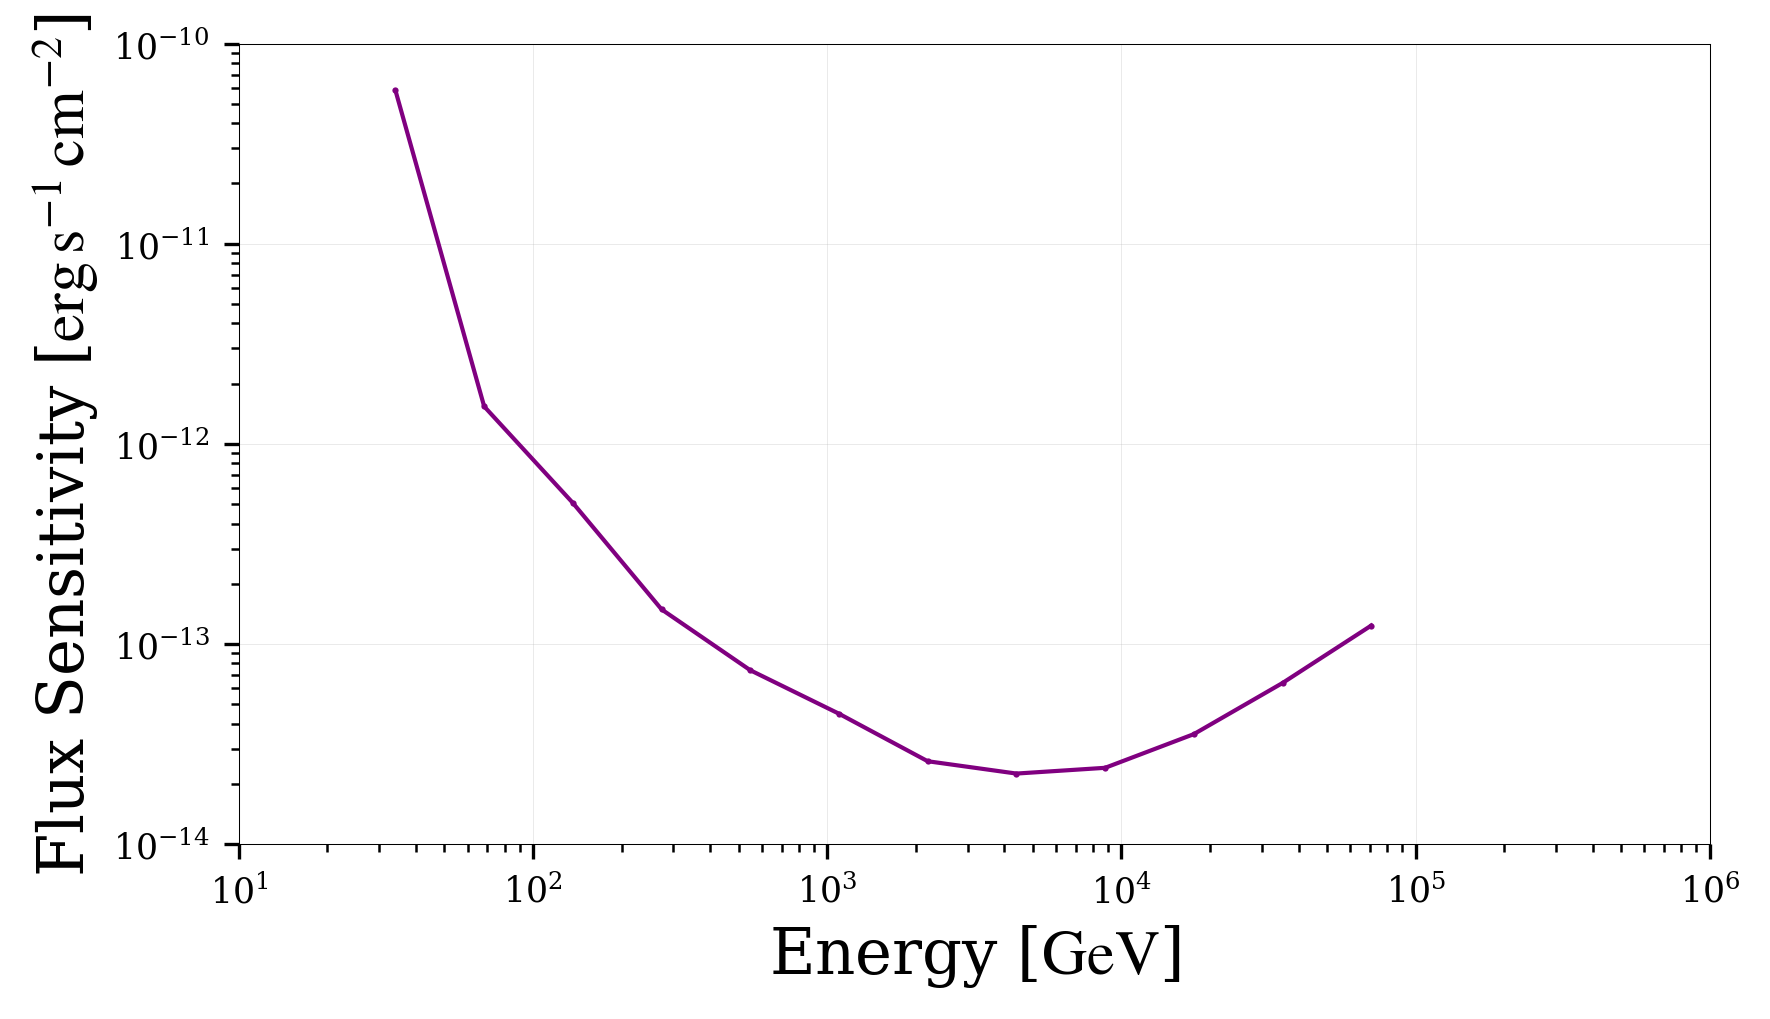

In [14]:
plot_sensitivity_from_table(sensitivity_table)

## Inspect counts

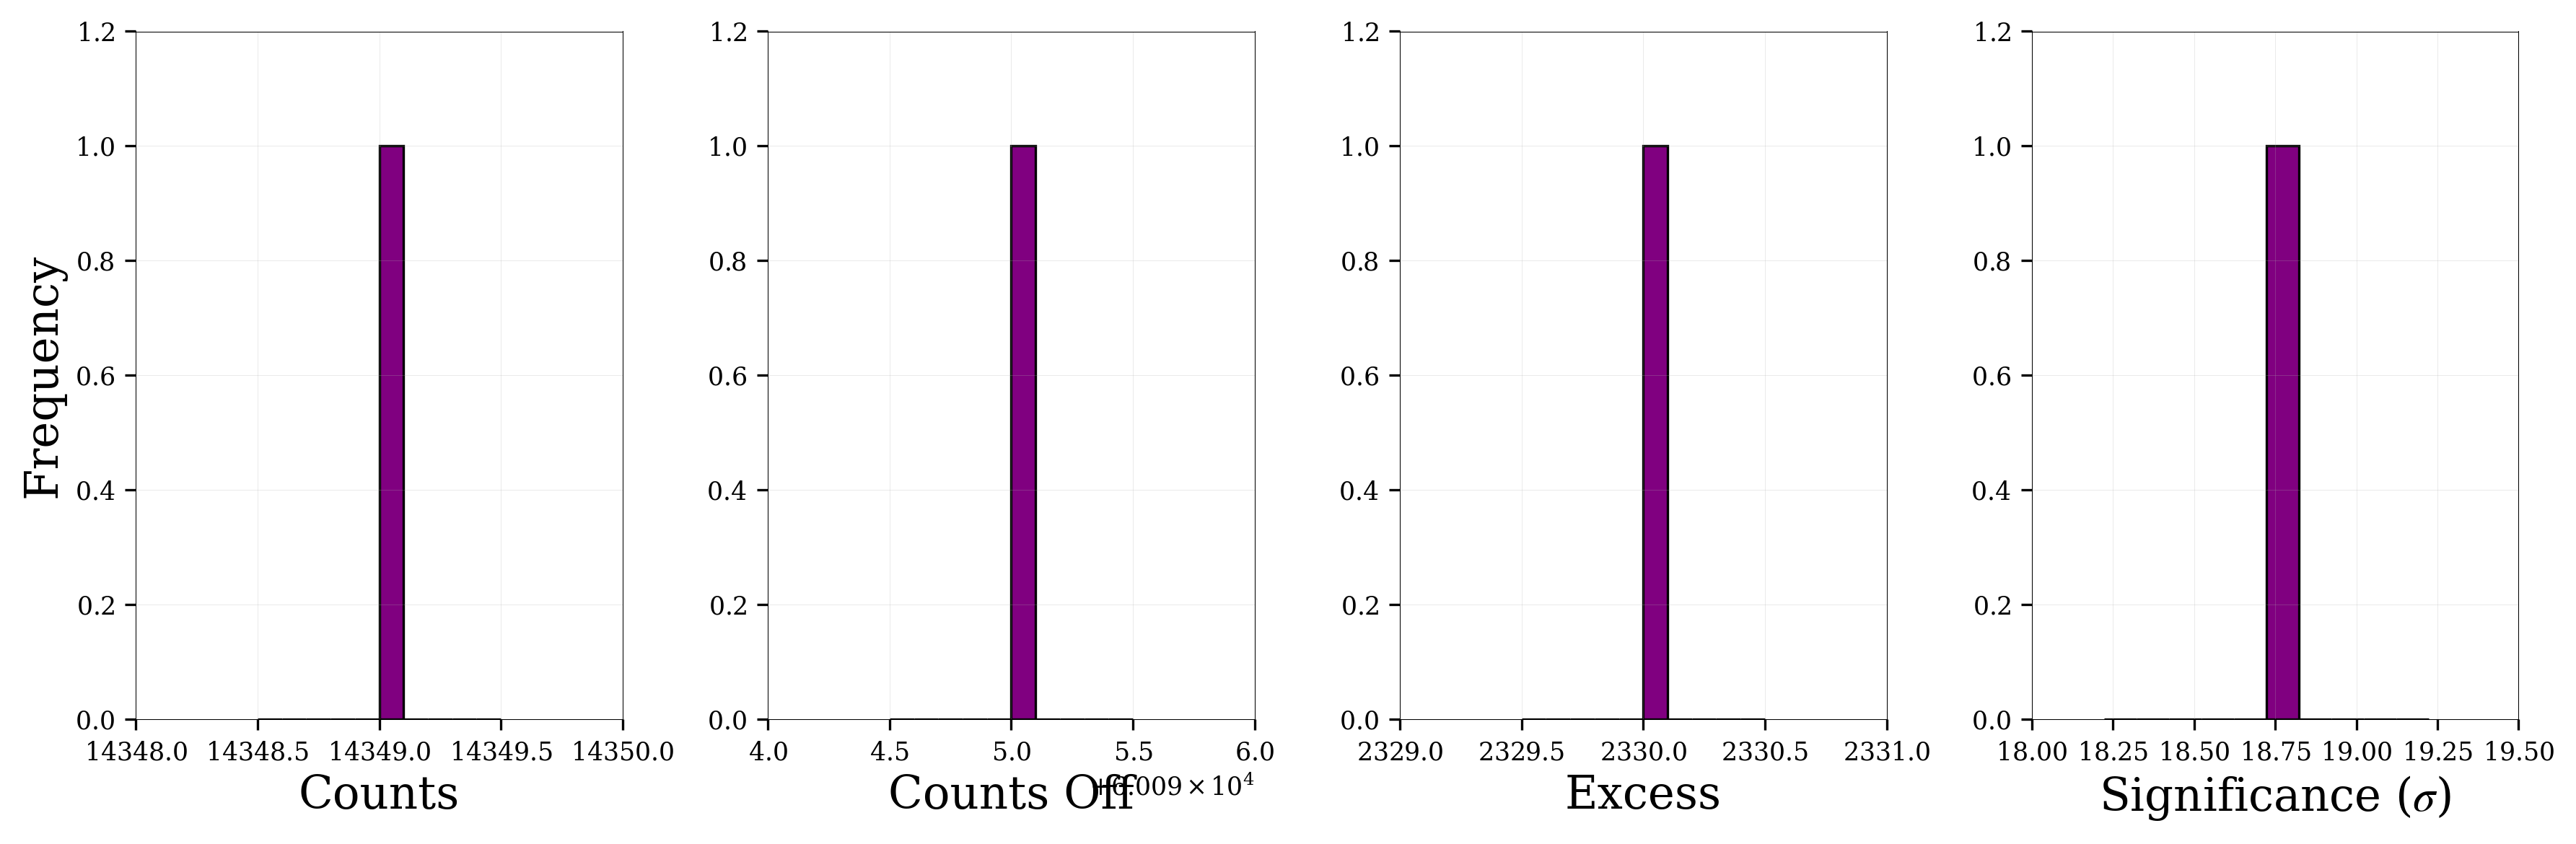

In [15]:
dataset_info = analysis.datasets.info_table()
show_hist_counts(dataset_info)

## Compare the fitted model with the sensitivity

<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='e2dnde [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>

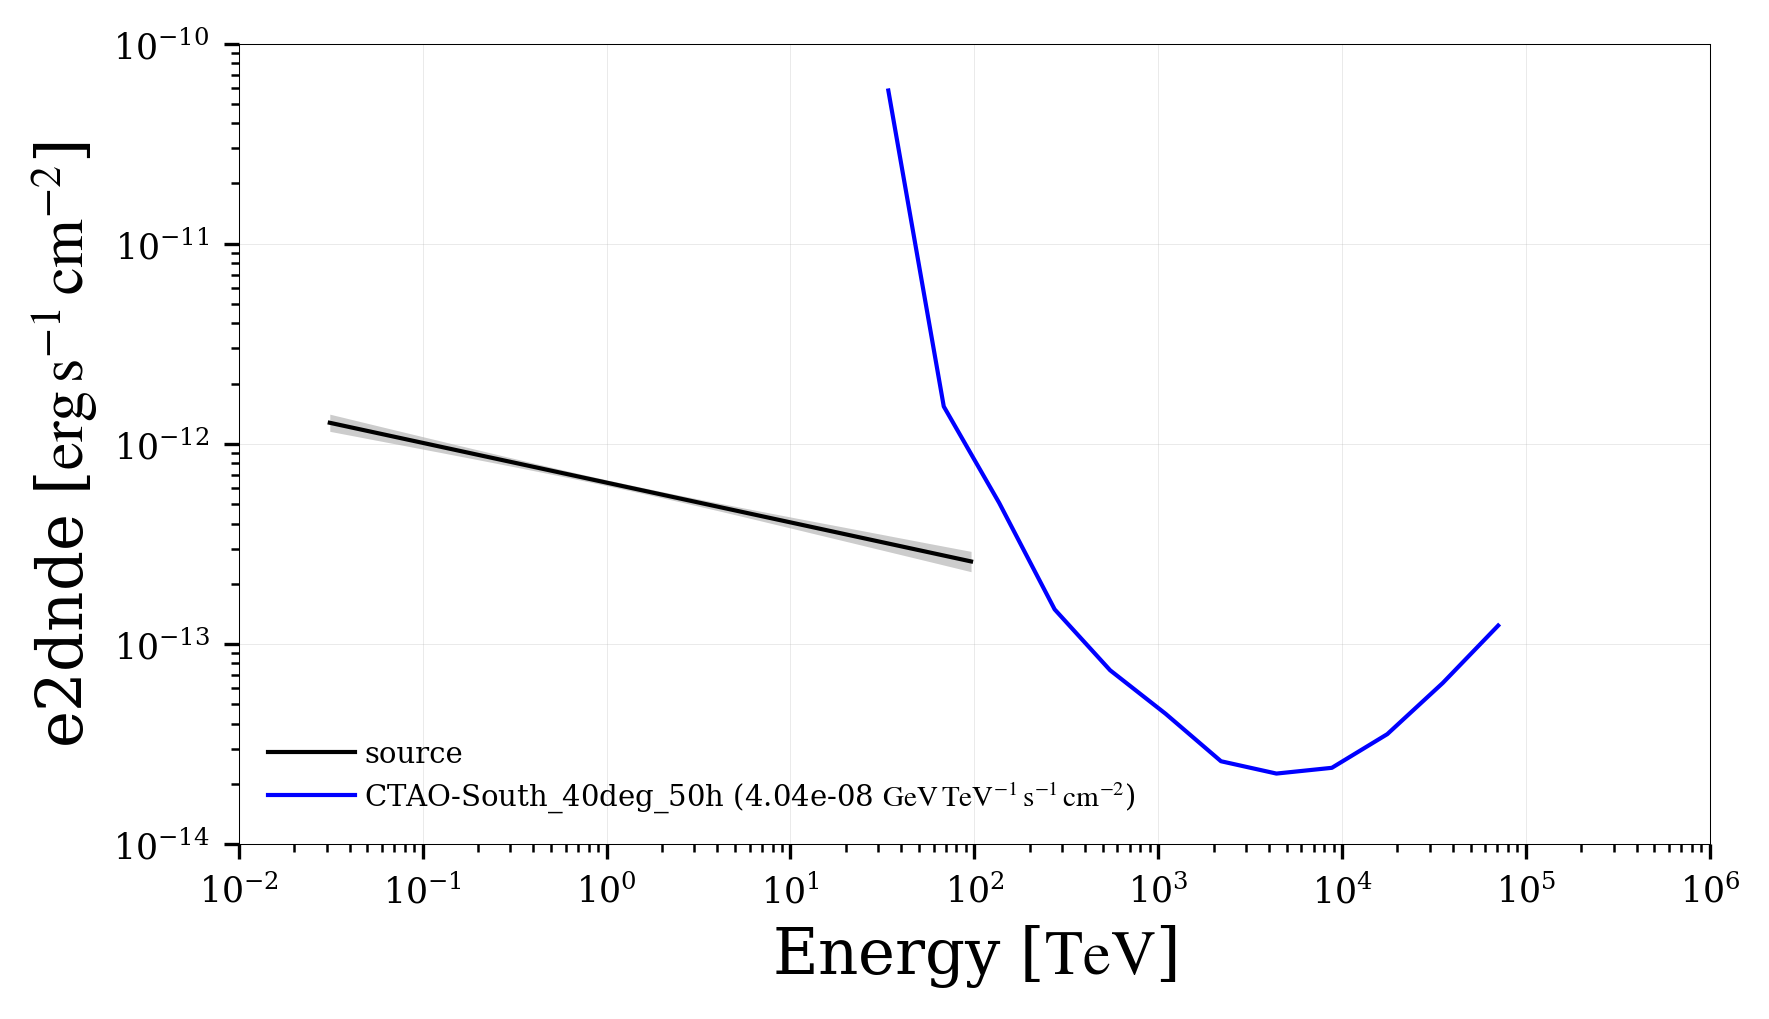

In [16]:
fitted_model = analysis.fit_result.models[0]

plot_irfs(
    [sensitivity_table],
    fitted_model,
    energy_bounds=[30 * u.GeV, 100 * u.TeV],
)

## Summary

This notebook demonstrated how to:

- select a target from the 1LHAASO catalog;
- estimate annual CTAO visibility;
- configure and simulate a CTAO observation;
- build a 1D ON/OFF spectrum dataset;
- fit a spectral model;
- estimate flux points;
- compute and visualize sensitivity and count information.